In [1]:
# Project Assignment Part 6 follows after Project Assignment Part 5

In [2]:
# Project Assignment Part 2

In [3]:
# Revised Questions
# Research Question 1:
# Is there a statistically significant difference in average shipment volume (Boxes_Shipped) among the top 10 performing salespeople?

# Research Question 2:
# Are there statistically significant differences in shipment volume (Boxes_Shipped) across the six countries represented in the dataset?

In [4]:
# Import and display data
import pandas as pd
df = pd.read_csv("Chocolate Sales (2).csv")

df.head()
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [5]:
# Data Cleaning and Preparation
# Only keep 'Sales Person', 'Country', and 'Boxes Shipped', as they are related to the research questions that I'm exploring. 
df = df[['Sales Person', 'Country', 'Boxes Shipped']].copy()

df

,Sales Person,Country,Boxes Shipped
0,Jehu Rudeforth,UK,180
1,Van Tuxwell,India,94
2,Gigi Bohling,India,91
3,Jan Morforth,Australia,342
4,Jehu Rudeforth,UK,184
...,...,...,...
3277,Karlen McCaffrey,Australia,354
3278,Jehu Rudeforth,USA,121
3279,Ches Bonnell,Canada,238
3280,Dotty Strutley,India,397


In [6]:
# Handling Missing Data 
df.isna().sum()

Sales Person     0
Country          0
Boxes Shipped    0
dtype: int64

In [7]:
# There is no missing value in any of the columns, therefore, no value needs to be dropped

In [8]:
# Data Transformations

In [9]:
# Re-label columns to ensure accurate process
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

df.columns

Index(['Sales_Person', 'Country', 'Boxes_Shipped'], dtype='object')

In [10]:
# Change column type
# Converting 'Sales_Person' and 'Country' to categorical makes the data structure align with the ANOVA design and improves clarity and efficiency in group-based analysis.
# 'Boxes_Shipped' represents numerical shipment volume and must remain a numeric type, therefore, the column type can remain as integers.
df['Sales_Person'] = df['Sales_Person'].astype('category')
df['Country'] = df['Country'].astype('category')

df.dtypes

Sales_Person     category
Country          category
Boxes_Shipped       int64
dtype: object

In [11]:
# Check for duplicated rows
any(df.duplicated())

True

In [12]:
# Drop duplicated rows
df = df.drop_duplicates().copy()

df

,Sales_Person,Country,Boxes_Shipped
0,Jehu Rudeforth,UK,180
1,Van Tuxwell,India,94
2,Gigi Bohling,India,91
3,Jan Morforth,Australia,342
4,Jehu Rudeforth,UK,184
...,...,...,...
3277,Karlen McCaffrey,Australia,354
3278,Jehu Rudeforth,USA,121
3279,Ches Bonnell,Canada,238
3280,Dotty Strutley,India,397


In [13]:
# Replace values
# No replacement needed for 'Sales_Person' or 'Boxes_Shipped'. 
# Fix inconsistent country naming / typos if they exist. If they don't, nothing needs to be changed. 
df['Country'].cat.categories

Index(['Australia', 'Canada', 'India', 'New Zealand', 'UK', 'USA'], dtype='object')

In [14]:
# Detect and filter outliers 
# IQR method
Q1 = df['Boxes_Shipped'].quantile(0.25)
Q3 = df['Boxes_Shipped'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Outlier_Flag'] = (df['Boxes_Shipped'] < lower) | (df['Boxes_Shipped'] > upper)
df['Outlier_Flag'].value_counts()

# Unnecessary to remove outliers as the research question 2 is about shipment volume variation.

Outlier_Flag
False    2847
True       73
Name: count, dtype: int64

In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2920 entries, 0 to 3281
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Sales_Person   2920 non-null   category
 1   Country        2920 non-null   category
 2   Boxes_Shipped  2920 non-null   int64   
 3   Outlier_Flag   2920 non-null   bool    
dtypes: bool(1), category(2), int64(1)
memory usage: 55.1 KB


In [16]:
# Project Assignment Part 3

In [17]:
# Processing Strings
# Cleaned column names in part 2

# Clean text columns used for grouping in ANOVA
df['Country'] = df['Country'].astype(str).str.strip().str.title()
df['Sales_Person'] = df['Sales_Person'].astype(str).str.strip().str.title()

# Replace inconsistent labels if needed (edit mapping to match your dataset)
country_map = {
    "Usa": "USA",
    "U.S.": "USA",
    "United States": "USA",
    "Uk": "United Kingdom"
}
df['Country'] = df['Country'].replace(country_map)

# Quick check of unique labels (useful to confirm string cleaning worked)
df['Country'].unique(), df['Sales_Person'].unique()

(array(['United Kingdom', 'India', 'Australia', 'New Zealand', 'USA',
        'Canada'], dtype=object),
 array(['Jehu Rudeforth', 'Van Tuxwell', 'Gigi Bohling', 'Jan Morforth',
        'Oby Sorrel', 'Gunar Cockshoot', 'Brien Boise',
        'Rafaelita Blaksland', 'Barr Faughny', 'Mallorie Waber',
        'Karlen Mccaffrey', "Marney O'Breen", 'Beverie Moffet',
        'Roddy Speechley', 'Curtice Advani', 'Husein Augar', 'Kaine Padly',
        'Dennison Crosswaite', "Wilone O'Kielt", 'Andria Kimpton',
        'Kelci Walkden', 'Camilla Castle', 'Madelene Upcott',
        'Dotty Strutley', 'Ches Bonnell'], dtype=object))

In [18]:
# Data Wrangling: Combining and Merging Datasets
# My project uses one dataset file, so there is no need to combine multiple files with concat. However, I created a derived summary table and merged it back to support Research Question 1.

sp_summary = (
    df.groupby('Sales_Person', as_index=False)
      .agg(Total_Boxes=('Boxes_Shipped', 'sum'),
           Num_Shipments=('Boxes_Shipped', 'count'),
           Avg_Boxes=('Boxes_Shipped', 'mean'))
)

sp_summary.head()

# Merge the summary back into the main dataset
df = df.merge(sp_summary, on='Sales_Person', how='left')

df.head()

,Sales_Person,Country,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes
0,Jehu Rudeforth,United Kingdom,180,False,20944,119,176.000000
1,Van Tuxwell,India,94,False,19118,129,148.201550
2,Gigi Bohling,India,91,False,17663,123,143.601626
3,Jan Morforth,Australia,342,False,22355,108,206.990741
4,Jehu Rudeforth,United Kingdom,184,False,20944,119,176.000000


In [19]:
# Merge the country summary
country_summary = (
    df.groupby('Country', as_index=False)
      .agg(Country_Total_Boxes=('Boxes_Shipped', 'sum'),
           Country_Num_Shipments=('Boxes_Shipped', 'count'),
           Country_Avg_Boxes=('Boxes_Shipped', 'mean'))
)

df = df.merge(country_summary, on='Country', how='left')

df.head()

,Sales_Person,Country,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes,Country_Total_Boxes,Country_Num_Shipments,Country_Avg_Boxes
0,Jehu Rudeforth,United Kingdom,180,False,20944,119,176.000000,85942,478,179.794979
1,Van Tuxwell,India,94,False,19118,129,148.201550,85407,497,171.845070
2,Gigi Bohling,India,91,False,17663,123,143.601626,85407,497,171.845070
3,Jan Morforth,Australia,342,False,22355,108,206.990741,95182,553,172.119349
4,Jehu Rudeforth,United Kingdom,184,False,20944,119,176.000000,85942,478,179.794979


In [20]:
# Data Wrangling: Reshaping and Pivoting
# Average 'Boxes_Shipped' by 'Country' (table form)
country_pivot = df.pivot_table(
    index='Country',
    values='Boxes_Shipped',
    aggfunc='mean'
)

country_pivot.sort_values('Boxes_Shipped', ascending=False)

,Boxes_Shipped
Country,
Canada,195.902386
United Kingdom,179.794979
Australia,172.119349
India,171.845070
New Zealand,166.801724
USA,164.160600


In [21]:
# Average 'Boxes_Shipped' by 'Sales_Person' (table form)
sales_pivot = df.pivot_table(
    index='Sales_Person',
    values='Boxes_Shipped',
    aggfunc='mean'
)

sales_pivot.sort_values('Boxes_Shipped', ascending=False).head(10)

,Boxes_Shipped
Sales_Person,
Karlen Mccaffrey,220.742188
Jan Morforth,206.990741
Dennison Crosswaite,201.126984
Dotty Strutley,200.680000
Marney O'Breen,197.181034
Beverie Moffet,193.433824
Oby Sorrel,190.244275
Camilla Castle,183.863636
Andria Kimpton,180.084906


In [22]:
# Make a two-level index, then unstack to a table
frame = df[['Country', 'Sales_Person', 'Boxes_Shipped']].groupby(['Country', 'Sales_Person']).sum()
frame2 = frame.unstack(level='Sales_Person') 

frame2.head()

Boxes_Shipped                                          \
Sales_Person Andria Kimpton Barr Faughny Beverie Moffet Brien Boise   
Country                                                               
Australia              3973         1842           6563        4329   
Canada                 5012         3839           3766        4982   
India                  2610         2789           4817        4571   
New Zealand            2944         4792           3414        4024   
USA                    1455         2594           4436        3432   

                                                                             \
Sales_Person Camilla Castle Ches Bonnell Curtice Advani Dennison Crosswaite   
Country                                                                       
Australia              3270         2770           3090                4552   
Canada                 1277         3950           2021                3676   
India                  3393         3922           4539                2726   
New Zealand            2577         3962           4514                4250   
USA                    3770         2373           3162                5821   

                                          ...                                 \
Sales_Person Dotty Strutley Gigi Bohling  ... Karlen Mccaffrey Kelci Walkden   
Country                                   ...                                  
Australia              3954         3650  ...             5602          5951   
Canada                 1677         1773  ...             6782          2696   
India                  3725         1670  ...             6385          5885   
New Zealand            2615         3262  ...             3093          2605   
USA                    5348         3752  ...             3727          4077   

                                                                       \
Sales_Person Madelene Upcott Mallorie Waber Marney O'Breen Oby Sorrel   
Country                                                                 
Australia               5623           3552           4170       2675   
Canada                  2537           5733           6685       6147   
India                    725           1672           2348       3564   
New Zealand             4268           2968           3549       3512   
USA                     3520           1963           3698       2794   

                                                                             
Sales_Person Rafaelita Blaksland Roddy Speechley Van Tuxwell Wilone O'Kielt  
Country                                                                      
Australia                   3940            1732        2288           2439  
Canada                      1982            3769        5033           1053  
India                       1700            3989        5240           2618  
New Zealand                  993            3473        1427           3623  
USA                         1654            4240        2220           1224  

[5 rows x 25 columns]

In [23]:
# Convert the table back into long format (like lecture melt)
frame2_reset = frame2.reset_index()
frame2_reset.columns

# Flatten multi-level column names
frame2_reset.columns = [
    col[0] if col[1] == '' else col[1]
    for col in frame2_reset.columns
]

frame2_reset.head()

melted = pd.melt(
    frame2_reset,
    id_vars='Country',
    var_name='Sales_Person',
    value_name='Boxes_Shipped'
)

melted

,Country,Sales_Person,Boxes_Shipped
0,Australia,Andria Kimpton,3973
1,Canada,Andria Kimpton,5012
2,India,Andria Kimpton,2610
3,New Zealand,Andria Kimpton,2944
4,USA,Andria Kimpton,1455
...,...,...,...
145,Canada,Wilone O'Kielt,1053
146,India,Wilone O'Kielt,2618
147,New Zealand,Wilone O'Kielt,3623
148,USA,Wilone O'Kielt,1224


In [24]:
# Project Assignment Part 4 
# Plotting and Visualization

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df[['Boxes_Shipped']].describe()

,Boxes_Shipped
count,2920.000000
mean,174.966096
std,124.402767
min,1.000000
25%,82.000000
50%,145.000000
75%,243.000000
max,778.000000


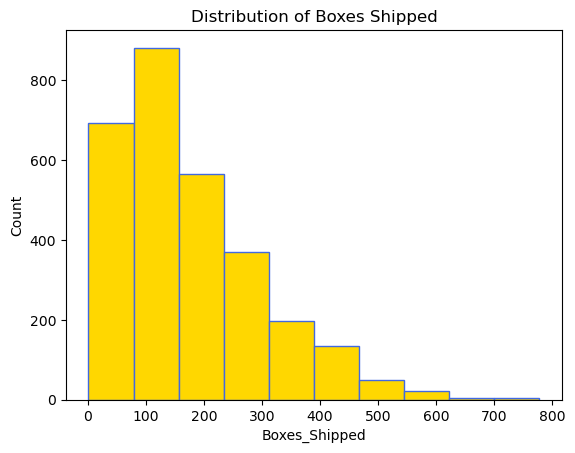

In [27]:
# Histogram of Boxes_Shipped (explore distribution + outliers)
plt.hist(df['Boxes_Shipped'], color='gold', edgecolor='royalblue')
plt.title('Distribution of Boxes Shipped')
plt.xlabel('Boxes_Shipped')
plt.ylabel('Count')
plt.show()

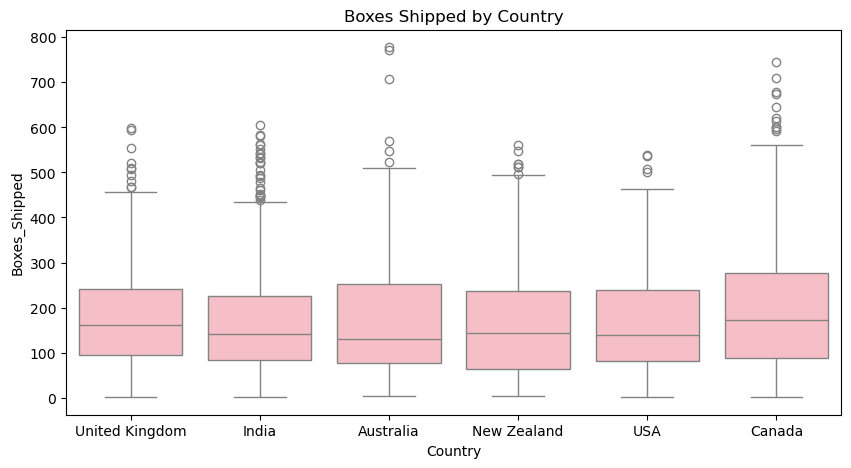

In [28]:
# Boxplot: Boxes_Shipped by Country (explore differences for RQ2)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Country', y='Boxes_Shipped', color='lightpink')
plt.title('Boxes Shipped by Country')
plt.xlabel('Country')
plt.ylabel('Boxes_Shipped')
plt.show()

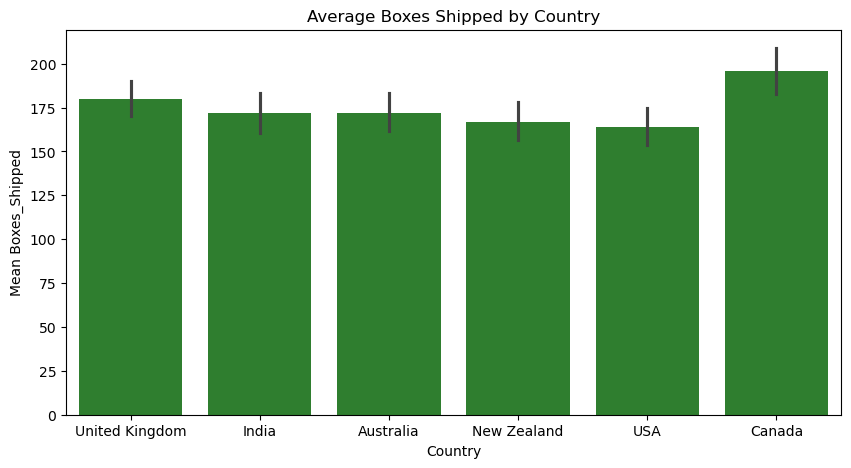

In [29]:
# Barplot: Mean Boxes_Shipped by Country (explore average differences for RQ2)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Country', y='Boxes_Shipped', estimator=np.mean, color='forestgreen')
plt.title('Average Boxes Shipped by Country')
plt.xlabel('Country')
plt.ylabel('Mean Boxes_Shipped')
plt.show()

In [30]:
# Top 10 salespeople (exploratory setup for RQ1) + boxplot/barplot
# Identify top 10 by total shipped
top10 = (
    df.groupby('Sales_Person')['Boxes_Shipped']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

df_top10 = df[df['Sales_Person'].isin(top10)].copy()
df_top10['Sales_Person'].nunique()

10

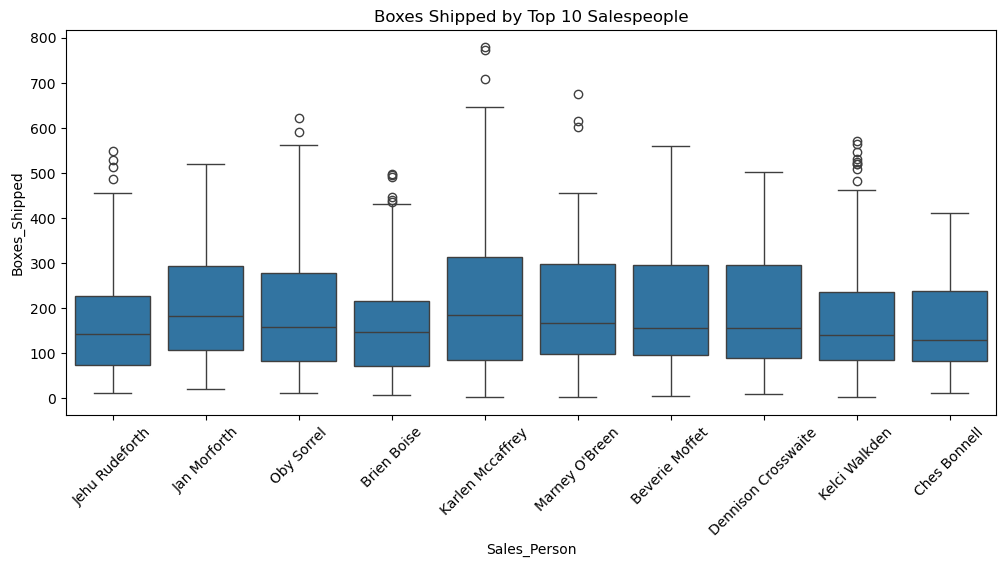

In [31]:
# Boxplot: Boxes_Shipped by Top 10 Salespeople
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_top10, x='Sales_Person', y='Boxes_Shipped')
plt.title('Boxes Shipped by Top 10 Salespeople')
plt.xlabel('Sales_Person')
plt.ylabel('Boxes_Shipped')
plt.xticks(rotation=45)
plt.show()

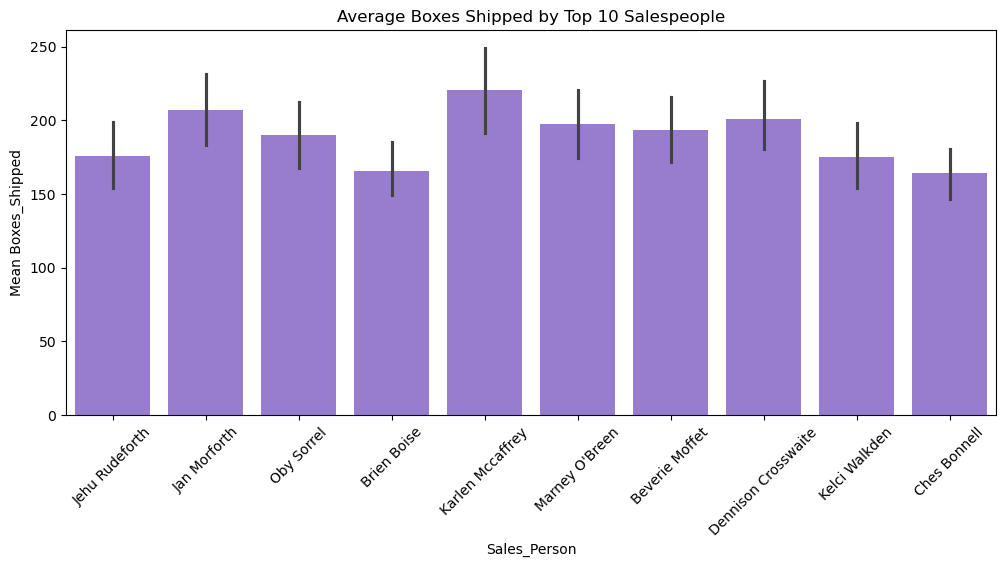

In [32]:
# Barplot: Mean Boxes_Shipped by Top 10 Salespeople
plt.figure(figsize=(12, 5))
sns.barplot(data=df_top10, x='Sales_Person', y='Boxes_Shipped', estimator=np.mean, color='mediumpurple')
plt.title('Average Boxes Shipped by Top 10 Salespeople')
plt.xlabel('Sales_Person')
plt.ylabel('Mean Boxes_Shipped')
plt.xticks(rotation=45)
plt.show()

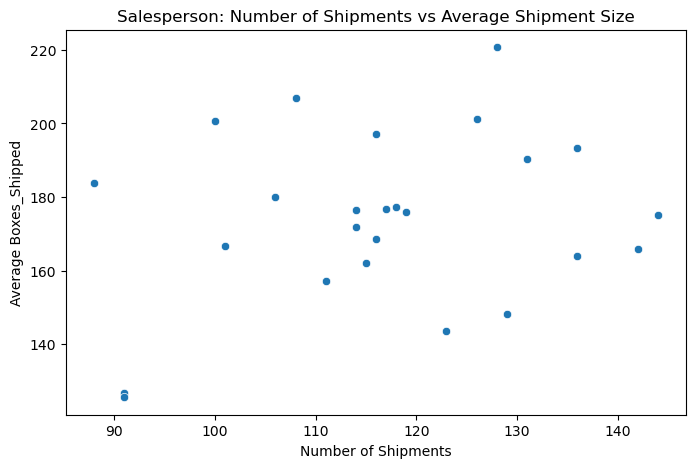

In [33]:
# Scatterplot: Total shipments vs average shipment size by salesperson
# This is exploratory and helps interpret “high performer” patterns beyond just one metric.
sp_summary = (
    df.groupby('Sales_Person', as_index=False)
      .agg(Total_Boxes=('Boxes_Shipped', 'sum'),
           Avg_Boxes=('Boxes_Shipped', 'mean'),
           Num_Shipments=('Boxes_Shipped', 'count'))
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sp_summary, x='Num_Shipments', y='Avg_Boxes')
plt.title('Salesperson: Number of Shipments vs Average Shipment Size')
plt.xlabel('Number of Shipments')
plt.ylabel('Average Boxes_Shipped')
plt.show()

In [34]:
# Project Assignment 5

In [35]:
# 1. Data Aggregation and Group Operations

In [36]:
# Group Boxes_Shipped by Country
grouped_country = df["Boxes_Shipped"].groupby(df["Country"])
grouped_country

In [37]:
# Mean shipment volume for each country
grouped_country.mean()

Country
Australia         172.119349
Canada            195.902386
India             171.845070
New Zealand       166.801724
USA               164.160600
United Kingdom    179.794979
Name: Boxes_Shipped, dtype: float64

In [38]:
# Group the full dataframe by Country
all_grouped_country = df.groupby("Country")
all_grouped_country.mean(numeric_only=True)

,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes,Country_Total_Boxes,Country_Num_Shipments,Country_Avg_Boxes
Country,,,,,,,,
Australia,172.119349,0.018083,20444.600362,117.195298,173.693480,95182.0,553.0,172.119349
Canada,195.902386,0.056399,21149.731020,119.737527,176.112644,90311.0,461.0,195.902386
India,171.845070,0.034205,21158.496982,119.818913,176.185553,85407.0,497.0,171.845070
New Zealand,166.801724,0.019397,20664.816810,118.187500,174.075562,77396.0,464.0,166.801724
USA,164.160600,0.008565,20769.693790,118.269807,174.976813,76663.0,467.0,164.160600
United Kingdom,179.794979,0.014644,20926.838912,119.424686,174.918671,85942.0,478.0,179.794979


In [39]:
# Count the number of rows in each country group
all_grouped_country.size()

Country
Australia         553
Canada            461
India             497
New Zealand       464
USA               467
United Kingdom    478
dtype: int64

In [40]:
# 2.1 Grouping Data

In [41]:
means = df["Boxes_Shipped"].groupby([df["Country"], df["Sales_Person"]]).mean()
means

Country         Sales_Person       
Australia       Andria Kimpton         198.650000
                Barr Faughny           122.800000
                Beverie Moffet         312.523810
                Brien Boise            144.300000
                Camilla Castle         181.666667
                                          ...    
United Kingdom  Oby Sorrel             214.827586
                Rafaelita Blaksland     97.384615
                Roddy Speechley        264.272727
                Van Tuxwell            126.521739
                Wilone O'Kielt          58.625000
Name: Boxes_Shipped, Length: 150, dtype: float64

In [42]:
means.unstack()

Sales_Person,Andria Kimpton,Barr Faughny,Beverie Moffet,Brien Boise,Camilla Castle,Ches Bonnell,Curtice Advani,Dennison Crosswaite,Dotty Strutley,Gigi Bohling,...,Karlen Mccaffrey,Kelci Walkden,Madelene Upcott,Mallorie Waber,Marney O'Breen,Oby Sorrel,Rafaelita Blaksland,Roddy Speechley,Van Tuxwell,Wilone O'Kielt
Country,,,,,,,,,,,,,,,,,,,,,
Australia,198.650000,122.800000,312.523810,144.300000,181.666667,131.904762,134.347826,206.909091,152.076923,152.083333,...,243.565217,247.958333,193.896552,142.080000,219.473684,140.789474,171.304348,123.714286,108.952381,101.625000
Canada,200.480000,182.809524,163.739130,237.238095,159.625000,232.352941,106.368421,193.473684,209.625000,126.642857,...,242.214286,134.800000,140.944444,220.500000,371.388889,267.260870,152.461538,163.869565,201.320000,175.500000
India,153.529412,199.214286,172.035714,163.250000,226.200000,135.241379,189.125000,136.300000,248.333333,119.285714,...,266.041667,189.838710,72.500000,128.615385,146.750000,162.000000,121.428571,181.318182,174.666667,187.000000
New Zealand,173.176471,159.733333,148.434783,182.909091,135.631579,152.384615,250.777778,250.000000,174.333333,171.684211,...,140.590909,130.250000,224.631579,156.210526,154.304348,175.600000,76.384615,157.863636,89.187500,157.521739
USA,132.272727,117.909091,233.473684,163.428571,198.421053,139.588235,225.857143,194.033333,232.521739,138.962963,...,186.350000,145.607143,207.058824,122.687500,194.631579,155.222222,110.266667,192.727273,158.571429,76.500000
United Kingdom,193.437500,213.000000,150.500000,110.700000,210.333333,204.269231,141.562500,239.833333,211.461538,142.240000,...,242.363636,190.047619,170.480000,128.583333,115.380952,214.827586,97.384615,264.272727,126.521739,58.625000


In [43]:
# Mean and standard deviation of shipment volume by Country
grouped_country.agg(["mean", "std"])

,mean,std
Country,,
Australia,172.119349,129.603297
Canada,195.902386,142.983372
India,171.845070,125.127508
New Zealand,166.801724,120.087853
USA,164.160600,111.428656
United Kingdom,179.794979,111.793891


In [44]:
# Custom labels like lecture
ftuples = [("Average", "mean"), ("Standard Deviation", "std")]
grouped_country.agg(ftuples)

,Average,Standard Deviation
Country,,
Australia,172.119349,129.603297
Canada,195.902386,142.983372
India,171.845070,125.127508
New Zealand,166.801724,120.087853
USA,164.160600,111.428656
United Kingdom,179.794979,111.793891


In [45]:
# 2.2 Grouping Salespeople for Research Question 1
# Find total boxes shipped by salesperson
sales_totals = df.groupby("Sales_Person")["Boxes_Shipped"].sum().sort_values(ascending=False)
sales_totals

Sales_Person
Karlen Mccaffrey       28255
Beverie Moffet         26307
Dennison Crosswaite    25342
Kelci Walkden          25205
Oby Sorrel             24922
Brien Boise            23552
Marney O'Breen         22873
Jan Morforth           22355
Ches Bonnell           22288
Jehu Rudeforth         20944
Madelene Upcott        20935
Kaine Padly            20674
Roddy Speechley        20110
Dotty Strutley         20068
Curtice Advani         19591
Gunar Cockshoot        19567
Van Tuxwell            19118
Andria Kimpton         19089
Barr Faughny           18625
Gigi Bohling           17663
Mallorie Waber         17431
Husein Augar           16846
Camilla Castle         16180
Rafaelita Blaksland    11535
Wilone O'Kielt         11426
Name: Boxes_Shipped, dtype: int64

In [46]:
# Select top 10 salespeople
top10_sales = sales_totals.head(10).index
top10_sales

Index(['Karlen Mccaffrey', 'Beverie Moffet', 'Dennison Crosswaite',
       'Kelci Walkden', 'Oby Sorrel', 'Brien Boise', 'Marney O'Breen',
       'Jan Morforth', 'Ches Bonnell', 'Jehu Rudeforth'],
      dtype='object', name='Sales_Person')

In [47]:
# Filter the dataframe to keep only top 10 salespeople
df_top10 = df[df["Sales_Person"].isin(top10_sales)].copy()
df_top10.head()

,Sales_Person,Country,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes,Country_Total_Boxes,Country_Num_Shipments,Country_Avg_Boxes
0,Jehu Rudeforth,United Kingdom,180,False,20944,119,176.000000,85942,478,179.794979
3,Jan Morforth,Australia,342,False,22355,108,206.990741,95182,553,172.119349
4,Jehu Rudeforth,United Kingdom,184,False,20944,119,176.000000,85942,478,179.794979
6,Oby Sorrel,United Kingdom,176,False,24922,131,190.244275,85942,478,179.794979
8,Jehu Rudeforth,New Zealand,59,False,20944,119,176.000000,77396,464,166.801724


In [48]:
# Group shipment volume by top 10 salespeople
grouped_sales = df_top10["Boxes_Shipped"].groupby(df_top10["Sales_Person"])
grouped_sales.mean()

Sales_Person
Beverie Moffet         193.433824
Brien Boise            165.859155
Ches Bonnell           163.882353
Dennison Crosswaite    201.126984
Jan Morforth           206.990741
Jehu Rudeforth         176.000000
Karlen Mccaffrey       220.742188
Kelci Walkden          175.034722
Marney O'Breen         197.181034
Oby Sorrel             190.244275
Name: Boxes_Shipped, dtype: float64

In [49]:
# Summary statistics for top 10 salespeople
grouped_sales.agg(["mean", "std", "count"])

,mean,std,count
Sales_Person,,,
Beverie Moffet,193.433824,132.920567,136
Brien Boise,165.859155,114.663714,142
Ches Bonnell,163.882353,104.711601,136
Dennison Crosswaite,201.126984,135.671838,126
Jan Morforth,206.990741,128.020186,108
Jehu Rudeforth,176.000000,127.133521,119
Karlen Mccaffrey,220.742188,162.318257,128
Kelci Walkden,175.034722,130.364117,144
Marney O'Breen,197.181034,135.318664,116


In [50]:
# 2.3 Apply Function to Grouped Data
# Define a function that returns the top n shipments by Boxes_Shipped
def top(df, n=5, column="Boxes_Shipped"):
    return df.sort_values(column, ascending=False)[:n]

top(df, n=5)

,Sales_Person,Country,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes,Country_Total_Boxes,Country_Num_Shipments,Country_Avg_Boxes
2625,Karlen Mccaffrey,Australia,778,True,28255,128,220.742188,95182,553,172.119349
1721,Karlen Mccaffrey,Australia,772,True,28255,128,220.742188,95182,553,172.119349
1986,Van Tuxwell,Canada,746,True,19118,129,148.201550,90311,461,195.902386
1016,Van Tuxwell,Canada,709,True,19118,129,148.201550,90311,461,195.902386
725,Karlen Mccaffrey,Australia,708,True,28255,128,220.742188,95182,553,172.119349


In [51]:
# Top 3 shipments for each country
df.groupby("Country").apply(top, n=3, column="Boxes_Shipped")

C:\Users\Colleen\AppData\Local\Temp\ipykernel_24912\1853698895.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("Country").apply(top, n=3, column="Boxes_Shipped")


Sales_Person         Country  Boxes_Shipped  \
Country                                                                
Australia      2625  Karlen Mccaffrey       Australia            778   
               1721  Karlen Mccaffrey       Australia            772   
               725   Karlen Mccaffrey       Australia            708   
Canada         1986       Van Tuxwell          Canada            746   
               1016       Van Tuxwell          Canada            709   
               2866       Van Tuxwell          Canada            679   
India          2075  Karlen Mccaffrey           India            605   
               1117  Karlen Mccaffrey           India            583   
               39    Karlen Mccaffrey           India            581   
New Zealand    2743    Beverie Moffet     New Zealand            560   
               2735       Kaine Padly     New Zealand            548   
               855        Kaine Padly     New Zealand            518   
USA            2595    Dotty Strutley             USA            538   
               1687    Dotty Strutley             USA            536   
               687     Dotty Strutley             USA            508   
United Kingdom 1379       Kaine Padly  United Kingdom            599   
               2305       Kaine Padly  United Kingdom            594   
               337        Kaine Padly  United Kingdom            554   

                     Outlier_Flag  Total_Boxes  Num_Shipments   Avg_Boxes  \
Country                                                                     
Australia      2625          True        28255            128  220.742188   
               1721          True        28255            128  220.742188   
               725           True        28255            128  220.742188   
Canada         1986          True        19118            129  148.201550   
               1016          True        19118            129  148.201550   
               2866          True        19118            129  148.201550   
India          2075          True        28255            128  220.742188   
               1117          True        28255            128  220.742188   
               39            True        28255            128  220.742188   
New Zealand    2743          True        26307            136  193.433824   
               2735          True        20674            117  176.700855   
               855           True        20674            117  176.700855   
USA            2595          True        20068            100  200.680000   
               1687          True        20068            100  200.680000   
               687           True        20068            100  200.680000   
United Kingdom 1379          True        20674            117  176.700855   
               2305          True        20674            117  176.700855   
               337           True        20674            117  176.700855   

                     Country_Total_Boxes  Country_Num_Shipments  \
Country                                                           
Australia      2625                95182                    553   
               1721                95182                    553   
               725                 95182                    553   
Canada         1986                90311                    461   
               1016                90311                    461   
               2866                90311                    461   
India          2075                85407                    497   
               1117                85407                    497   
               39                  85407                    497   
New Zealand    2743                77396                    464   
               2735                77396                    464   
               855                 77396                    464   
USA            2595                76663                    467   
               1687                766

In [52]:
# Top 2 shipments for each top-10 salesperson
df_top10.groupby("Sales_Person").apply(top, n=2, column="Boxes_Shipped")

C:\Users\Colleen\AppData\Local\Temp\ipykernel_24912\776346292.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top10.groupby("Sales_Person").apply(top, n=2, column="Boxes_Shipped")


Sales_Person         Country  Boxes_Shipped  \
Sales_Person                                                                   
Beverie Moffet      2743       Beverie Moffet     New Zealand            560   
                    865        Beverie Moffet     New Zealand            518   
Brien Boise         1800          Brien Boise          Canada            497   
                    814           Brien Boise          Canada            495   
Ches Bonnell        1374         Ches Bonnell  United Kingdom            411   
                    2301         Ches Bonnell  United Kingdom            406   
Dennison Crosswaite 1997  Dennison Crosswaite             USA            501   
                    1590  Dennison Crosswaite          Canada            488   
Jan Morforth        109          Jan Morforth           India            520   
                    1835         Jan Morforth  United Kingdom            507   
Jehu Rudeforth      1670       Jehu Rudeforth          Canada            548   
                    2577       Jehu Rudeforth          Canada            529   
Karlen Mccaffrey    2625     Karlen Mccaffrey       Australia            778   
                    1721     Karlen Mccaffrey       Australia            772   
Kelci Walkden       1185        Kelci Walkden       Australia            570   
                    2171        Kelci Walkden           India            563   
Marney O'Breen      2725       Marney O'Breen          Canada            674   
                    843        Marney O'Breen          Canada            614   
Oby Sorrel          2900           Oby Sorrel          Canada            621   
                    1058           Oby Sorrel          Canada            591   

                          Outlier_Flag  Total_Boxes  Num_Shipments  \
Sales_Person                                                         
Beverie Moffet      2743          True        26307            136   
                    865           True        26307            136   
Brien Boise         1800          True        23552            142   
                    814           True        23552            142   
Ches Bonnell        1374         False        22288            136   
                    2301         False        22288            136   
Dennison Crosswaite 1997          True        25342            126   
                    1590          True        25342            126   
Jan Morforth        109           True        22355            108   
                    1835          True        22355            108   
Jehu Rudeforth      1670          True        20944            119   
                    2577          True        20944            119   
Karlen Mccaffrey    2625          True        28255            128   
                    1721          True        28255            128   
Kelci Walkden       1185          True        25205            144   
                    2171          True        25205            144   
Marney O'Breen      2725          True        22873            116   
                    843           True        22873            116   
Oby Sorrel          2900          True        24922            131   
                    1058          True        24922            131   

                           Avg_Boxes  Country_Total_Boxes  \
Sales_Person                                                
Beverie Moffet      2743  193.433824                77396   
                    865   193.433824                77396   
Brien Boise         1800  165.859155                90311   
                    814   165.859155                90311   
Ches Bonnell        1374  163.882353                85942   
                    2301  163.882353                85942   
Dennison Crosswaite 1997  201.126984                76663   
                    1590  201.126984                90311   
Jan Morforth        109   206.990741                85407   
                    1835  206.990741                85942   

In [53]:
# 3. Pivot Tables and Cross-Tabulation

In [54]:
# Pivot table: average shipment volume by Country
df.pivot_table(index="Country", values="Boxes_Shipped")

,Boxes_Shipped
Country,
Australia,172.119349
Canada,195.902386
India,171.845070
New Zealand,166.801724
USA,164.160600
United Kingdom,179.794979


In [55]:
# Pivot table: mean and standard deviation by Country
df.pivot_table(index="Country",
               values="Boxes_Shipped",
               aggfunc=["mean", "std"])

,mean,std
,Boxes_Shipped,Boxes_Shipped
Country,,
Australia,172.119349,129.603297
Canada,195.902386,142.983372
India,171.845070,125.127508
New Zealand,166.801724,120.087853
USA,164.160600,111.428656
United Kingdom,179.794979,111.793891


In [56]:
# Pivot table: average shipment volume by Country and Sales_Person
df.pivot_table(index=["Country", "Sales_Person"],
               values="Boxes_Shipped")

Boxes_Shipped
Country        Sales_Person                      
Australia      Andria Kimpton          198.650000
               Barr Faughny            122.800000
               Beverie Moffet          312.523810
               Brien Boise             144.300000
               Camilla Castle          181.666667
...                                           ...
United Kingdom Oby Sorrel              214.827586
               Rafaelita Blaksland      97.384615
               Roddy Speechley         264.272727
               Van Tuxwell             126.521739
               Wilone O'Kielt           58.625000

[150 rows x 1 columns]

In [57]:
# Pivot table for top 10 salespeople only
df_top10.pivot_table(index="Sales_Person",
                     values="Boxes_Shipped",
                     aggfunc=["mean", "std", "count"])

,mean,std,count
,Boxes_Shipped,Boxes_Shipped,Boxes_Shipped
Sales_Person,,,
Beverie Moffet,193.433824,132.920567,136
Brien Boise,165.859155,114.663714,142
Ches Bonnell,163.882353,104.711601,136
Dennison Crosswaite,201.126984,135.671838,126
Jan Morforth,206.990741,128.020186,108
Jehu Rudeforth,176.000000,127.133521,119
Karlen Mccaffrey,220.742188,162.318257,128
Kelci Walkden,175.034722,130.364117,144


In [58]:
# Cross-Tabulation: frequency of shipments by Country
pd.crosstab(df["Country"], columns="Count")

col_0,Count
Country,
Australia,553
Canada,461
India,497
New Zealand,464
USA,467
United Kingdom,478


In [59]:
# Cross-Tabulation: frequency of shipments by Sales Person
pd.crosstab(df["Sales_Person"], columns="Count")

col_0,Count
Sales_Person,
Andria Kimpton,106
Barr Faughny,115
Beverie Moffet,136
Brien Boise,142
Camilla Castle,88
Ches Bonnell,136
Curtice Advani,114
Dennison Crosswaite,126
Dotty Strutley,100


In [60]:
# Cross-Tabulation: country by Sales Person
pd.crosstab(df["Country"], df["Sales_Person"])

Sales_Person,Andria Kimpton,Barr Faughny,Beverie Moffet,Brien Boise,Camilla Castle,Ches Bonnell,Curtice Advani,Dennison Crosswaite,Dotty Strutley,Gigi Bohling,...,Karlen Mccaffrey,Kelci Walkden,Madelene Upcott,Mallorie Waber,Marney O'Breen,Oby Sorrel,Rafaelita Blaksland,Roddy Speechley,Van Tuxwell,Wilone O'Kielt
Country,,,,,,,,,,,,,,,,,,,,,
Australia,20,15,21,30,18,21,23,22,26,24,...,23,24,29,25,19,19,23,14,21,24
Canada,25,21,23,21,8,17,19,19,8,14,...,28,20,18,26,18,23,13,23,25,6
India,17,14,28,28,15,29,24,20,15,14,...,24,31,10,13,16,22,14,22,30,14
New Zealand,17,30,23,22,19,26,18,17,15,19,...,22,20,19,19,23,20,13,22,16,23
USA,11,22,19,21,19,17,14,30,23,27,...,20,28,17,16,19,18,15,22,14,16
United Kingdom,16,13,22,20,9,26,16,18,13,25,...,11,21,25,12,21,29,13,11,23,8


In [61]:
# Cross-Tabulation: Totals
pd.crosstab(df["Country"], df["Sales_Person"], margins=True)

Sales_Person,Andria Kimpton,Barr Faughny,Beverie Moffet,Brien Boise,Camilla Castle,Ches Bonnell,Curtice Advani,Dennison Crosswaite,Dotty Strutley,Gigi Bohling,...,Kelci Walkden,Madelene Upcott,Mallorie Waber,Marney O'Breen,Oby Sorrel,Rafaelita Blaksland,Roddy Speechley,Van Tuxwell,Wilone O'Kielt,All
Country,,,,,,,,,,,,,,,,,,,,,
Australia,20,15,21,30,18,21,23,22,26,24,...,24,29,25,19,19,23,14,21,24,553
Canada,25,21,23,21,8,17,19,19,8,14,...,20,18,26,18,23,13,23,25,6,461
India,17,14,28,28,15,29,24,20,15,14,...,31,10,13,16,22,14,22,30,14,497
New Zealand,17,30,23,22,19,26,18,17,15,19,...,20,19,19,23,20,13,22,16,23,464
USA,11,22,19,21,19,17,14,30,23,27,...,28,17,16,19,18,15,22,14,16,467
United Kingdom,16,13,22,20,9,26,16,18,13,25,...,21,25,12,21,29,13,11,23,8,478
All,106,115,136,142,88,136,114,126,100,123,...,144,118,111,116,131,91,114,129,91,2920


In [62]:
df.head()
df_top10.head()

,Sales_Person,Country,Boxes_Shipped,Outlier_Flag,Total_Boxes,Num_Shipments,Avg_Boxes,Country_Total_Boxes,Country_Num_Shipments,Country_Avg_Boxes
0,Jehu Rudeforth,United Kingdom,180,False,20944,119,176.000000,85942,478,179.794979
3,Jan Morforth,Australia,342,False,22355,108,206.990741,95182,553,172.119349
4,Jehu Rudeforth,United Kingdom,184,False,20944,119,176.000000,85942,478,179.794979
6,Oby Sorrel,United Kingdom,176,False,24922,131,190.244275,85942,478,179.794979
8,Jehu Rudeforth,New Zealand,59,False,20944,119,176.000000,77396,464,166.801724


In [63]:
# Project Assignment Part 6

In [64]:
# Descriptive Statistics
df['Boxes_Shipped'].describe()

count    2920.000000
mean      174.966096
std       124.402767
min         1.000000
25%        82.000000
50%       145.000000
75%       243.000000
max       778.000000
Name: Boxes_Shipped, dtype: float64

In [65]:
# Average shipment volume by country
df.groupby("Country")["Boxes_Shipped"].mean()

Country
Australia         172.119349
Canada            195.902386
India             171.845070
New Zealand       166.801724
USA               164.160600
United Kingdom    179.794979
Name: Boxes_Shipped, dtype: float64

In [66]:
# Average shipment volume by salesperson
df.groupby("Sales_Person")["Boxes_Shipped"].mean()

Sales_Person
Andria Kimpton         180.084906
Barr Faughny           161.956522
Beverie Moffet         193.433824
Brien Boise            165.859155
Camilla Castle         183.863636
Ches Bonnell           163.882353
Curtice Advani         171.850877
Dennison Crosswaite    201.126984
Dotty Strutley         200.680000
Gigi Bohling           143.601626
Gunar Cockshoot        168.681034
Husein Augar           166.792079
Jan Morforth           206.990741
Jehu Rudeforth         176.000000
Kaine Padly            176.700855
Karlen Mccaffrey       220.742188
Kelci Walkden          175.034722
Madelene Upcott        177.415254
Mallorie Waber         157.036036
Marney O'Breen         197.181034
Oby Sorrel             190.244275
Rafaelita Blaksland    126.758242
Roddy Speechley        176.403509
Van Tuxwell            148.201550
Wilone O'Kielt         125.560440
Name: Boxes_Shipped, dtype: float64

In [67]:
# ANOVA – Shipment Volume by Country - Research Question 2
from scipy import stats
groups_country = []

for name, group in df.groupby("Country"):
    groups_country.append(group["Boxes_Shipped"])

anova_country = stats.f_oneway(*groups_country)

anova_country

F_onewayResult(statistic=np.float64(4.0007149993275375), pvalue=np.float64(0.001279513189023862))

In [68]:
# A one-way ANOVA test was conducted to examine whether the average shipment volume (Boxes_Shipped) differs across countries. The results show a statistically significant difference in mean shipment volume among the countries, F = 4.00, p = 0.0013. Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected. This indicates that shipment volume varies across countries, suggesting that some countries tend to have larger average shipment sizes than others.

In [69]:
# Identify Top 10 Salespeople
top10_sales = (
    df.groupby("Sales_Person")["Boxes_Shipped"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

df_top10 = df[df["Sales_Person"].isin(top10_sales)].copy()

top10_sales

Index(['Karlen Mccaffrey', 'Beverie Moffet', 'Dennison Crosswaite',
       'Kelci Walkden', 'Oby Sorrel', 'Brien Boise', 'Marney O'Breen',
       'Jan Morforth', 'Ches Bonnell', 'Jehu Rudeforth'],
      dtype='object', name='Sales_Person')

In [70]:
# ANOVA – Shipment Volume by Top 10 Salespeople - Research Question 1
groups_sales = []

for name, group in df_top10.groupby("Sales_Person"):
    groups_sales.append(group["Boxes_Shipped"])

anova_sales = stats.f_oneway(*groups_sales)

anova_sales

F_onewayResult(statistic=np.float64(2.616491837324008), pvalue=np.float64(0.0053624378441752794))

In [71]:
# A one-way ANOVA test was conducted to examine whether the average shipment volume (Boxes_Shipped) differs among the top 10 performing salespeople. The results indicate a statistically significant difference in mean shipment volume across these salespeople, F = 2.62, p = 0.0054. Since the p-value is less than the 0.05 significance level, the null hypothesis is rejected. This suggests that some salespeople consistently ship higher volumes than others.

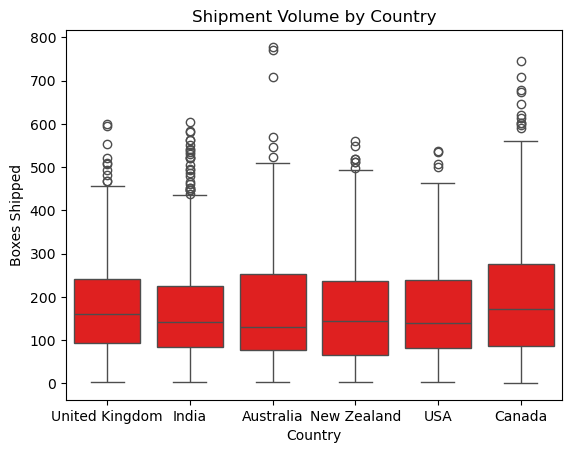

In [72]:
# Visualization of ANOVA Groups

# Shipment volume by country
sns.boxplot(data=df, x="Country", y="Boxes_Shipped", color="red")

plt.title("Shipment Volume by Country")
plt.xlabel("Country")
plt.ylabel("Boxes Shipped")

plt.show()

In [73]:
# The boxplot illustrates the distribution of shipment volume (Boxes_Shipped) across the six countries in the dataset. While the median shipment sizes appear relatively similar among most countries, Canada shows a slightly higher median shipment volume compared to the others. Additionally, several countries display a number of high-value outliers, indicating occasional large shipments. Overall, the visualization suggests some variation in shipment volume across countries, which supports the use of ANOVA to further test whether these differences are statistically significant.

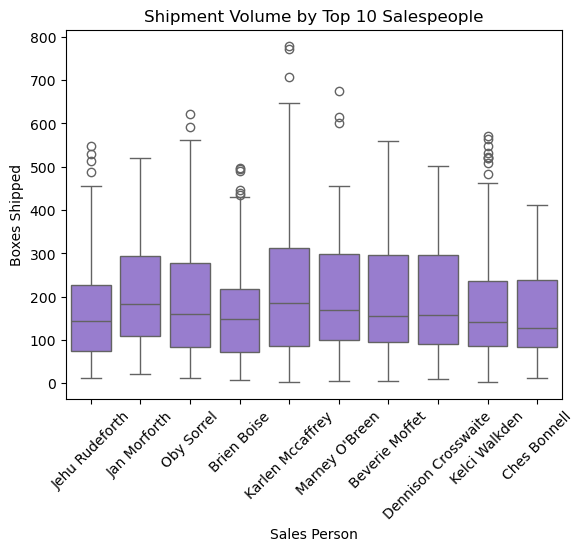

In [74]:
# Shipment volume by top 10 salespeople
sns.boxplot(data=df_top10, x="Sales_Person", y="Boxes_Shipped", color="mediumpurple")

plt.xticks(rotation=45)

plt.title("Shipment Volume by Top 10 Salespeople")
plt.xlabel("Sales Person")
plt.ylabel("Boxes Shipped")

plt.show()

In [75]:
# The boxplot shows the distribution of shipment volume (Boxes_Shipped) among the top 10 salespeople in the dataset. While the median shipment sizes are fairly similar across most salespeople, some individuals, such as Karlen Mccaffrey and Marney O’Breen, appear to have slightly higher median shipment volumes and a wider range of shipment sizes. Several salespeople also display high-value outliers, indicating occasional large shipments. Overall, the visualization suggests some variation in shipment volume among the top 10 salespeople, which supports the use of ANOVA to determine whether these differences are statistically significant.

In [76]:
# Post-Hoc Test (Tukey HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [77]:
# Tukey test for country
tukey_country = pairwise_tukeyhsd(
    endog=df["Boxes_Shipped"],
    groups=df["Country"],
    alpha=0.05
)

print(tukey_country)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2     meandiff p-adj   lower    upper  reject
------------------------------------------------------------------
  Australia         Canada   23.783 0.0289   1.4672 46.0988   True
  Australia          India  -0.2743    1.0 -22.1449 21.5963  False
  Australia    New Zealand  -5.3176 0.9841  -27.594 16.9588  False
  Australia            USA  -7.9587 0.9112 -30.1962 14.2787  False
  Australia United Kingdom   7.6756 0.9211 -14.4227 29.7739  False
     Canada          India -24.0573 0.0327 -46.9376 -1.1771   True
     Canada    New Zealand -29.1007 0.0049 -52.3691 -5.8322   True
     Canada            USA -31.7418 0.0014  -54.973 -8.5106   True
     Canada United Kingdom -16.1074 0.3491 -39.2054  6.9906  False
      India    New Zealand  -5.0433 0.9888 -27.8852 17.7985  False
      India            USA  -7.6845 0.9301 -30.4883 15.1194  False
      India United Kingdom   7.9499  0.918 -14.7183 30.6181  F

In [78]:
# A Tukey HSD post-hoc test was conducted to determine which countries differ significantly in average shipment volume after the ANOVA indicated a significant difference. The results show that Canada has significantly different mean shipment volumes compared to Australia, India, New Zealand, and the USA (p < 0.05). However, no statistically significant differences were found between most of the other country pairs. These findings suggest that Canada’s shipment volumes differ notably from several other countries, while the remaining countries have relatively similar average shipment sizes.

In [79]:
# Tukey test for salespeople
tukey_sales = pairwise_tukeyhsd(
    endog=df_top10["Boxes_Shipped"],
    groups=df_top10["Sales_Person"],
    alpha=0.05
)

print(tukey_sales)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1              group2       meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------------
     Beverie Moffet         Brien Boise -27.5747 0.7613 -77.2785  22.1291  False
     Beverie Moffet        Ches Bonnell -29.5515 0.6933 -79.7888  20.6859  False
     Beverie Moffet Dennison Crosswaite   7.6932    1.0 -43.5312  58.9176  False
     Beverie Moffet        Jan Morforth  13.5569 0.9985 -39.8373  66.9512  False
     Beverie Moffet      Jehu Rudeforth -17.4338  0.988 -69.4344  34.5667  False
     Beverie Moffet    Karlen Mccaffrey  27.3084 0.7976 -23.7079  78.3246  False
     Beverie Moffet       Kelci Walkden -18.3991 0.9757 -67.9338  31.1356  False
     Beverie Moffet      Marney O'Breen   3.7472    1.0 -48.6108  56.1052  False
     Beverie Moffet          Oby Sorrel  -3.1895    1.0  -53.904  47.5249  False
        Brien Boise        C

In [80]:
# A Tukey HSD post-hoc test was conducted to determine which of the top 10 salespeople differ significantly in average shipment volume after the ANOVA indicated a significant difference. The results show that Karlen Mccaffrey has significantly higher mean shipment volumes compared to Brien Boise and Ches Bonnell (p < 0.05). However, no statistically significant differences were found among the remaining salesperson pairs. This suggests that most of the top salespeople have relatively similar shipment volumes, with Karlen Mccaffrey standing out as having higher shipment volumes than a few others.

In [81]:
# The analysis shows that shipment volume (Boxes_Shipped) varies across both countries and salespeople. The ANOVA results indicate that there is a statistically significant difference in average shipment volume across countries, suggesting that some countries tend to ship larger volumes than others. The Tukey HSD post-hoc test further reveals that Canada differs significantly from several other countries in terms of shipment volume. Additionally, the ANOVA conducted on the top 10 salespeople also shows a significant difference in shipment volume. The Tukey test suggests that Karlen Mccaffrey ships significantly higher volumes compared to Brien Boise and Ches Bonnell, while most other salespeople have relatively similar shipment volumes. Overall, these findings indicate that both regional factors and individual salesperson performance contribute to differences in shipment volumes.